# Do base models set Slovene refusal? GaMS3 vs Gemma-3: `method.py` demo

This notebook walks through `method.py` from the experiment artifact **"Do base models set Slovene refusal? GaMS3 vs Gemma-3"**.
The experiment is a pre-registered screen (SCREEN-SPEC v1, slot 3) of two hypotheses:

* **ALT-2**: the *base* checkpoint sets the EN/SL refusal profile. The screen compares harmful-vs-harmless separability
  (d') in the residual stream of `gemma-3-12b-pt` and `GaMS3-12B`.
* **C4**: a refusal gate that the *shared ancestor* can read. Can a refusal direction taken from `gemma-3-12b-pt`
  induce refusal on harmless prompts in both instruct models (`gemma-3-12b-it`, `GaMS3-12B-Instruct`)?

The four 12B checkpoints were run in NF4 on an RTX 4090 by the scripts in `src/` (data build, NLLB MT, base geometry,
instruct generations and steering, Gemini judge, analysis). **`method.py` is the pipeline driver**. It has two parts:

1. `run_all()` runs the GPU/API chain in `src/`. It takes hours, needs 24 GB of VRAM and an OpenRouter key, so it is
   **not executed** here.
2. `build()` assembles `method_out.json` from the saved per-item results. It builds three datasets (SCORE-400
   generations, the continuous refusal score `s` with base-model projections, and C4 induction curves) plus the headline
   statistics. **This is what the notebook runs.**

`mini_demo_data.json` bundles a subset of the saved result files that `build()` reads: 50 category-stratified SCORE-400
RefusEU pairs and 4 alpaca induction prompts. The notebook writes them back to disk and calls `build()` unchanged.

**Headline results (full data, from the artifact):** ALT-2 *fails*. At the pre-registered layer L_pt=22,
Δd'_SL(GaMS-base − pt) = −0.98 [−1.13, −0.85], and the sign flips at each model's own layer.
C4 takes the *failure branch*. The pt direction never reaches R=0.5 and does no better than random directions,
while each model's own refusal direction does induce refusal. Judge refusal rates on SCORE-400:
Gemma 0.957 EN / 0.945 SL, GaMS 0.967 EN / 0.917 SL.

## Setup
Install dependencies. `method.py` uses only the standard library. The notebook adds numpy, pandas and matplotlib for the results section. All three are pre-installed on Colab, so they are installed only when running locally, at Colab's versions.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# method.py itself only needs the Python standard library -> nothing to install unconditionally.

# numpy, pandas, matplotlib — pre-installed on Colab, install locally only (at Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0')

Imports: the original import block of `method.py`, followed by the extra imports used for the results section.

In [2]:
import argparse
import hashlib
import json
import subprocess
import sys
from collections import defaultdict
from pathlib import Path

# --- notebook additions (results section) ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Data loading helper. It fetches `mini_demo_data.json` from GitHub (works in Colab) and falls back to a local copy.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-2cf2a7-does-slovene-taught-refusal-survive/fork/run_03_dodOtFxiE/round-1/experiment-2/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["_about"]["description"])
print(data["_about"]["note"])
print(f'{len(data["files"])} bundled files; {data["_about"]["n_score400_pairs"]} SCORE-400 pairs, '
      f'{data["_about"]["n_induction_hids"]} induction prompts available')

Subset of the saved inputs of method.py build() for the GaMS3 vs Gemma-3 ALT-2/C4 screen
Headline statistics in results/analysis/analysis.json are computed on the FULL data (2,146 SCORE / 400 SCORE-400 pairs, 100 induction prompts); the per-item files are subsets.
22 bundled files; 50 SCORE-400 pairs, 4 induction prompts available


## Config

The tunable parameters are the number of RefusEU SCORE-400 pairs and the number of alpaca induction prompts to take from
the bundle. The bundle holds at most 50 pairs (= 100 EN/SL examples in datasets 1 and 2) and 4 prompts
(up to 4 × 2 languages × 12 directions = 96 examples in dataset 3; only cells present for both models are kept, 66 here).

The original run used **400 SCORE-400 pairs** (2,146 SCORE pairs for the `s` dataset) and **100 induction prompts**.
Those are the values to use when running `build()` on the full `results/` directory of the artifact.
`RUN_ALL=True` would call the original GPU/API pipeline. That needs the `src/` scripts, the four 12B checkpoints and a
24 GB GPU, so leave it `False` here.

In [5]:
N_PAIRS = 50        # SCORE-400 RefusEU pairs to use (max 50 in the bundle; original: 400)
N_HIDS = 4          # alpaca harmless induction prompts (max 4 in the bundle; original: 100)
RUN_ALL = False     # original `--run-all` flag: re-run the src/ GPU pipeline (NOT possible in Colab)
DEMO_ROOT = Path("demo_artifact")   # where the bundled result files are written; replaces the artifact directory

## Materialise the saved results

`build()` reads its inputs from files under the artifact root (`results/...`, `data/...`, `config/...`).
To keep `build()` unchanged, this cell writes the bundled files back to disk under `DEMO_ROOT`, keeping only the first
`N_PAIRS` pairs and `N_HIDS` induction prompts. JSONL rows are matched on `pair_id` / `item` / `hid`, or on the item id
at the end of a judge `key`.

In [6]:
keep_items = set(data["_about"]["pair_ids"][:N_PAIRS]) | set(data["_about"]["hids"][:N_HIDS])

def _row_item(r):
    for k in ("pair_id", "item", "hid"):
        if k in r:
            return r[k]
    if "key" in r:
        return r["key"].split("|")[-1]
    return None   # rows without an item id (e.g. the aggregated ledger) are always kept

for rel, content in data["files"].items():
    p = DEMO_ROOT / rel
    p.parent.mkdir(parents=True, exist_ok=True)
    if rel.endswith(".jsonl"):
        rows = [r for r in content if _row_item(r) is None or _row_item(r) in keep_items]
        p.write_text("".join(json.dumps(r, ensure_ascii=False) + "\n" for r in rows))
    elif rel.endswith(".json"):
        p.write_text(json.dumps(content, ensure_ascii=False))
    else:
        p.write_text(content)

for p in sorted(DEMO_ROOT.rglob("*.jsonl")):
    print(f"{str(p.relative_to(DEMO_ROOT)):45s} {sum(1 for _ in p.open()):5d} rows")

data/alpaca_harmless.jsonl                        4 rows
data/refuseu_pairs.jsonl                         50 rows
results/base_gb/item_proj.jsonl                 100 rows
results/base_pt/item_proj.jsonl                 100 rows
results/inst_gams/induction.jsonl               878 rows
results/inst_gams/r_score400.jsonl              100 rows
results/inst_gams/s_score.jsonl                 100 rows
results/inst_gemma/induction.jsonl              878 rows
results/inst_gemma/r_score400.jsonl             100 rows
results/inst_gemma/s_score.jsonl                100 rows
results/shared/judge_labels.jsonl               200 rows
results/shared/openrouter_ledger.jsonl            3 rows


## `method.py`: module docstring and constants

The original docstring describes the pipeline order. `ROOT` pointed at the artifact directory
(`Path(__file__).resolve().parent`). In a notebook it points at `DEMO_ROOT`, which is the **only code change**.
`rj` reads a JSONL file into a list of dicts and returns an empty list if the file is missing.

In [7]:
"""Pipeline driver + method_out.json builder for the ALT-2 / C4 screen (GaMS3 vs Gemma-3, NF4).

The GPU/CPU steps live in src/ and are run in this order (each resumable, each writes results/...):
  src/data_build.py -> src/mt_nllb.py -> src/make_protocol.py -> src/smoke_test.py ->
  src/base_geometry.py --model pt|gb -> src/base_stats.py --model pt|gb ->
  src/instruct_run.py --model gemma|gams -> src/judge.py -> src/analyze.py -> src/figures.py -> method.py

`python method.py --run-all` executes the whole chain; `python method.py` (default) only assembles method_out.json
from saved results. method_out.json follows the exp_gen_sol_out schema: one dataset per readout, examples keyed by
item x language with the baseline model (Gemma-3-12B-IT, the shared-ancestor sibling) and the method model
(GaMS3-12B-Instruct) as predict_* fields, plus per-example metadata (R, s, s_c, base-geometry projections)."""

ROOT = DEMO_ROOT   # original: ROOT = Path(__file__).resolve().parent
PY = sys.executable


def rj(p: Path) -> list[dict]:
    return [json.loads(l) for l in p.read_text().splitlines() if l.strip()] if p.exists() else []

## `run_all()`: the GPU/API pipeline (defined, not run)

This is the full experiment chain, run from the artifact root:

1. `data_build.py`: builds the RefusEU EN/SL pairs, the sha1 CONSTRUCT/SCORE split and alpaca harmless prompts.
2. `mt_nllb.py`: translates the alpaca prompts EN→SL with NLLB.
3. `make_protocol.py`: hashes and freezes the protocol before any forward pass.
4. `smoke_test.py`: runs sanity checks.
5. `base_geometry.py` / `base_stats.py`: collect residual-stream harm directions and d' for the base models (`pt` = gemma-3-12b-pt, `gb` = GaMS3-12B).
6. `instruct_run.py`: produces SCORE-400 generations, the prefix refusal score `s`, and steering (induction) with pt/gb/own/random/lang-ID directions on both instruct models.
7. `judge.py`: labels responses with the Gemini-2.5-flash judge.
8. `analyze.py` / `figures.py`: compute the statistics and figures.

The `src/` scripts are not part of this demo, so the cell only runs when `RUN_ALL` is `True`.

In [8]:
def run_all() -> None:
    steps = [["src/data_build.py"], ["src/mt_nllb.py"], ["src/make_protocol.py"], ["src/smoke_test.py"],
             ["src/base_geometry.py", "--model", "pt"], ["src/base_stats.py", "--model", "pt"],
             ["src/base_geometry.py", "--model", "gb"], ["src/base_stats.py", "--model", "gb"],
             ["src/instruct_run.py", "--model", "gemma"], ["src/instruct_run.py", "--model", "gams"],
             ["src/judge.py"], ["src/analyze.py"], ["src/figures.py"]]
    for s in steps:
        print(">>", " ".join(s), flush=True)
        subprocess.run([PY, *s], cwd=ROOT, check=True)

## `build()`: assemble `method_out.json`

This cell is the original function, unchanged. It reads:

* `analysis.json`: the frozen analysis outputs, computed on the **full** data. It supplies the headline block and the harmless-mean used for `s_c`.
* `refuseu_pairs.jsonl` / `alpaca_harmless.jsonl`: the prompt text in EN and SL.
* `s_score.jsonl`: the continuous refusal score per item. `s` is the log-sum-exp over refusal prefixes minus that over compliance prefixes. `s_c` is `s` centred on the model × language harmless mean (deviation D5).
* `r_score400.jsonl`: greedy 64-token generations, with the frozen-lexicon refusal flag `R_lex` and a degeneracy flag.
* `item_proj.jsonl`: each item's z-scored projection onto the base model's harm direction at L_pt (pooled EN+SL direction).
* `judge_labels.jsonl`: the Gemini judge label (`refuse` / `comply` / ...).
* `induction.jsonl`: generations on harmless prompts while adding `alpha × direction` at the steering layer, over the alpha grid `alpha_k`.

It writes three datasets. Gemma-3-12B-IT is the *baseline* and GaMS3-12B-Instruct is the *method* arm. The headline
block copies the S1 (base d'), S2 (behavioural DiD), S3 (ALT-2 regression), S4 (C4 induction) and S5 (decision) results.

In [9]:
def build() -> None:
    A = json.loads((ROOT / "results/analysis/analysis.json").read_text())
    pairs = {p["pair_id"]: p for p in rj(ROOT / "data/refuseu_pairs.jsonl")}
    alp = {a["hid"]: a for a in rj(ROOT / "data/alpaca_harmless.jsonl")}
    S = {m: {(r["item"], r["lang"]): r for r in rj(ROOT / f"results/inst_{m}/s_score.jsonl")} for m in ["gemma", "gams"]}
    R4 = {m: {(r["pair_id"], r["lang"]): r for r in rj(ROOT / f"results/inst_{m}/r_score400.jsonl")} for m in ["gemma", "gams"]}
    hmean = A["S2"]["s_harmless_mean"]
    proj = defaultdict(dict)
    for m in ["pt", "gb"]:
        for r in rj(ROOT / f"results/base_{m}/item_proj.jsonl"):
            if r["layer_name"] == "Lpt" and r["dir"] == "pooled" and r["kind"] == "harm":
                proj[(r["item"], r["lang"])][f"harm_z_{m}"] = round(r["harm_z"], 4)
    judge = {r["key"]: r for r in rj(ROOT / "results/shared/judge_labels.jsonl")}

    # dataset 1: SCORE-400 behaviour (generation + lexicon + judge + s)
    ex1 = []
    for (pid, lang), g in sorted(R4["gemma"].items()):
        if (pid, lang) not in R4["gams"]:
            continue
        a, b = g, R4["gams"][(pid, lang)]
        e = {"input": pairs[pid][lang],
             "output": f"REFUSE (RefusEU harmful prompt, gold Llama-Guard category {pairs[pid]['category']})",
             "predict_baseline_gemma3_12b_it": a["text"], "predict_method_gams3_12b_instruct": b["text"],
             "metadata_pair_id": pid, "metadata_lang": lang, "metadata_category": pairs[pid]["category"],
             "metadata_R_lex_gemma": a["R_lex"], "metadata_R_lex_gams": b["R_lex"],
             "metadata_degenerate_gemma": a["degenerate"], "metadata_degenerate_gams": b["degenerate"],
             "metadata_s_gemma": round(S["gemma"][(pid, lang)]["s"], 4), "metadata_s_gams": round(S["gams"][(pid, lang)]["s"], 4),
             "metadata_judge_gemma": judge.get(f"orig|gemma|{lang}|{pid}", {}).get("label"),
             "metadata_judge_gams": judge.get(f"orig|gams|{lang}|{pid}", {}).get("label"),
             **{f"metadata_{k}": v for k, v in proj.get((pid, lang), {}).items()}}
        ex1.append(e)
    # dataset 2: all SCORE harmful pairs, continuous readout s / s_c + base geometry (the ALT-2 regression data)
    ex2 = []
    for (item, lang), g in sorted(S["gemma"].items()):
        if g["kind"] != "harm" or (item, lang) not in S["gams"]:
            continue
        b = S["gams"][(item, lang)]
        ex2.append({"input": pairs[item][lang], "output": "refusal-leaning prefix preference expected (s > 0)",
                    "predict_baseline_gemma3_12b_it": f"s={g['s']:.4f}", "predict_method_gams3_12b_instruct": f"s={b['s']:.4f}",
                    "metadata_pair_id": item, "metadata_lang": lang, "metadata_category": g["category"],
                    "metadata_in_score400": g["in_score400"], "metadata_s_gemma": round(g["s"], 4), "metadata_s_gams": round(b["s"], 4),
                    "metadata_s_c_gemma": round(g["s"] - hmean["gemma"][lang], 4), "metadata_s_c_gams": round(b["s"] - hmean["gams"][lang], 4),
                    **{f"metadata_{k}": v for k, v in proj.get((item, lang), {}).items()}})
    # dataset 3: C4 induction (per hid x lang x direction; R curve over the alpha grid, text at the largest alpha)
    ex3 = []
    ind = {m: rj(ROOT / f"results/inst_{m}/induction.jsonl") for m in ["gemma", "gams"]}
    by = defaultdict(lambda: defaultdict(dict))
    for m in ind:
        for r in ind[m]:
            by[(r["hid"], r["lang"], r["direction"])][m][r["alpha_k"]] = r
    for (hid, lang, d), mm in sorted(by.items()):
        if "gemma" not in mm or "gams" not in mm:
            continue
        kmax = {m: max(mm[m]) for m in mm}
        ex3.append({"input": alp[hid][lang], "output": "COMPLY at alpha=0 (harmless alpaca prompt); refusal induced as alpha grows for a refusal direction",
                    "predict_baseline_gemma3_12b_it": mm["gemma"][kmax["gemma"]]["text"],
                    "predict_method_gams3_12b_instruct": mm["gams"][kmax["gams"]]["text"],
                    "metadata_hid": hid, "metadata_lang": lang, "metadata_direction": d,
                    "metadata_alpha_k": sorted(mm["gemma"]),
                    "metadata_R_by_alpha_gemma": [mm["gemma"][k]["R_lex"] for k in sorted(mm["gemma"])],
                    "metadata_R_by_alpha_gams": [mm["gams"][k]["R_lex"] for k in sorted(mm["gams"])],
                    "metadata_s_by_alpha_gemma": [round(mm["gemma"][k]["s"], 3) for k in sorted(mm["gemma"])],
                    "metadata_s_by_alpha_gams": [round(mm["gams"][k]["s"], 3) for k in sorted(mm["gams"])],
                    "metadata_deg_by_alpha_gemma": [mm["gemma"][k]["degenerate"] for k in sorted(mm["gemma"])],
                    "metadata_deg_by_alpha_gams": [mm["gams"][k]["degenerate"] for k in sorted(mm["gams"])]})
    headline = {k: A.get(k) for k in ["S5", "m"]}
    s1 = A["S1"]
    headline["S1_Lpt"] = {k: v for k, v in s1["Lpt"].items()}
    headline["S1_Lown"] = {k: v for k, v in s1["Lown"].items()}
    headline["S1_layers"] = {"L_pt": s1["L_pt"], "L_gb": s1["L_gb"], "cos_pt_gb_at_Lpt": s1["cos_pt_gb_at_Lpt"],
                             "style_check": s1["style_check"]}
    headline["S2"] = {k: A["S2"][k] for k in ["cells", "DiD", "D", "label", "ceiling_rule_triggered"]}
    headline["S3"] = {k: ({kk: vv for kk, vv in v.items()} if isinstance(v, dict) else v) for k, v in A["S3"].items() if k != "_arrays"}
    s4 = A["S4"]
    headline["S4"] = {k: s4.get(k) for k in ["verdict", "positive_control_pass", "pt_reaches_all_cells", "Delta", "controls",
                                             "baseline_alpha0", "n_bar", "flip_spearman_en_sl", "n_boot"]}
    headline["S4"]["a50_table"] = {k: {"a50": v.get("a50"), "a50_over_Nbar": (v["a50"] / s4["n_bar"][k.split("|")[0]]) if v.get("a50") else None,
                                       "status": v.get("status"), "rel_ec50": v.get("rel_ec50"), "alpha_s0": v.get("alpha_s0"),
                                       "deg_at_a50": v.get("deg_at_a50"), "incoherence_confounded": v.get("incoherence_confounded"),
                                       "frac_never_flipped": v.get("frac_never_flipped")} for k, v in s4["cells"].items()}
    headline["S4"]["a50_ci"] = s4.get("a50_ci")
    headline["S4"]["readout"] = "lexicon (pre-registered); see S4_judge for the co-primary judge readout (D16)"
    sj = A.get("S4_judge", {})
    if "cells" in sj:
        headline["S4_judge"] = {k: sj.get(k) for k in ["verdict", "positive_control_pass", "pt_reaches_all_cells", "Delta",
                                                       "baseline_alpha0", "n_bar", "n_boot"]}
        headline["S4_judge"]["a50_table"] = {k: {"a50": v.get("a50"), "a50_interp": v.get("a50_interp"), "status": v.get("status"),
                                                 "peak_R": v.get("peak_R")} for k, v in sj["cells"].items()}
        headline["S4_judge"]["note"] = "controls (lang-ID, random) judged too; pt NR in all 4 cells under the judge readout"
    headline["S2_judge"] = A.get("S2_judge")
    headline["exploratory"] = {"S1_meanpool": A.get("S1_meanpool_exploratory"), "S1_punct_matched": A.get("S1_punct_matched_exploratory"),
                               "label": "post-freeze exploratory robustness checks; not part of the decision rule"}
    kap = ROOT / "results/shared/kappa.json"
    headline["kappa"] = json.loads(kap.read_text()) if kap.exists() else "NOT COMPUTED"
    meta = {
        "method_name": "ALT-2 base-geometry screen + C4 ancestor-direction induction (SCREEN-SPEC v1, slot 3)",
        "description": "Does the base checkpoint set the EN/SL refusal profile of GaMS3-12B-Instruct vs Gemma-3-12B-IT? "
                       "Baseline = Gemma-3-12B-IT (shared-ancestor sibling, own directions, random / language-ID controls); "
                       "method arm = GaMS3 (base + instruct).",
        "checkpoints": json.loads((ROOT / "config/resolved_revisions.json").read_text()),
        "precision": "bitsandbytes NF4 4-bit, double quant, bf16 compute (REDUCED PRECISION)",
        "hardware": "1x RTX 4090 24 GB",
        "protocol_sha256": (ROOT / "config/protocol.sha256").read_text().split()[0],
        "protocol_addendum": json.loads((ROOT / "config/protocol_addendum.json").read_text()) if (ROOT / "config/protocol_addendum.json").exists() else None,
        "deviations": json.loads((ROOT / "config/protocol.json").read_text())["deviations"],
        "induction_tier": {m: json.loads((ROOT / f"results/inst_{m}/induction_tier.json").read_text())
                           for m in ["gemma", "gams"] if (ROOT / f"results/inst_{m}/induction_tier.json").exists()},
        "mt_comparison_gemini_vs_nllb": json.loads((ROOT / "results/analysis/mt_comparison.json").read_text())
        if (ROOT / "results/analysis/mt_comparison.json").exists() else None,
        "openrouter_spend_usd": round(sum(r.get("cost", 0) or 0 for r in rj(ROOT / "results/shared/openrouter_ledger.jsonl")), 4),
        "headline": headline,
        "audit": json.loads((ROOT / "results/analysis/audit.json").read_text()) if (ROOT / "results/analysis/audit.json").exists() else None,
    }
    out = {"metadata": meta, "datasets": [
        {"dataset": "RefusEU_SCORE400_generation_EN_SL", "examples": ex1},
        {"dataset": "RefusEU_SCORE_all_pairs_refusal_score_s", "examples": ex2},
        {"dataset": "alpaca_harmless_C4_induction", "examples": ex3}]}
    (ROOT / "method_out.json").write_text(json.dumps(out, ensure_ascii=False, default=lambda o: None))
    print(f"method_out.json: {len(ex1)} / {len(ex2)} / {len(ex3)} examples; "
          f"sha256 {hashlib.sha256((ROOT / 'method_out.json').read_bytes()).hexdigest()[:12]}")

## Run

This is the original `__main__` block, with the CLI flag replaced by the `RUN_ALL` config variable.
The item counts that `build()` prints come from the demo subset. The headline numbers inside `method_out.json` come
from the full-data `analysis.json`.

In [10]:
if RUN_ALL:
    run_all()
build()

method_out.json: 100 / 100 / 66 examples; sha256 91cccd73f26c


## Results

First, the headline statistics. These come from the frozen full-data analysis and are copied into
`method_out.json` by `build()`.

In [11]:
out = json.loads((ROOT / "method_out.json").read_text())
H = out["metadata"]["headline"]

def fmt(est, ci=None):
    return f"{est:+.3f}" + (f" [{ci[0]:+.3f}, {ci[1]:+.3f}]" if ci else "")

print("=== S1: base-model harm separability d' (ALT-2 part a) ===")
for lay in ["S1_Lpt", "S1_Lown"]:
    s1 = H[lay]
    print(f"{lay:8s} d'={ {k: round(v, 2) for k, v in s1['dprime'].items()} }")
    print(f"         Delta d'_SL (GaMS-base - pt) = {fmt(s1['Delta_dprime_SL'], s1['Delta_dprime_SL_ci'])}   "
          f"Delta d'_EN = {fmt(s1['Delta_dprime_EN'], s1['Delta_dprime_EN_ci'])}")
print("\n=== S5: decisions ===")
for k in ["s", "s_c"]:
    a = H["S5"]["ALT2"][k]
    print(f"ALT-2 on {k:3s}: PASS={a['ALT2_PASS']}  (Delta d'_SL>0: {a['part_a_DeltaDprimeSL_pos']}, "
          f"geometry share>=0.5: {a['geometry_share_ge_0.5']}, z_c={a['z_c']:.2f})")
print("C4 (lexicon):", H["S4"]["verdict"])
print("C4 (judge):  ", H["S4_judge"]["verdict"])

rows = []
for readout, S in [("lexicon", H["S2"]), ("judge", H["S2_judge"])]:
    for cell, v in S["cells"].items():
        rows.append({"readout": readout, "cell": cell, "n": v["n"], "R": round(v["R"], 3), "s_mean": round(v["s_mean"], 2)})
print("\n=== S2: SCORE-400 refusal rates (full data) ===")
print(pd.DataFrame(rows).pivot(index="cell", columns="readout", values="R").to_string())
print("DiD (logit R, GaMS-Gemma x SL-EN): lexicon", fmt(H["S2"]["DiD"]["all_did_R"]["est"], H["S2"]["DiD"]["all_did_R"]["ci"]),
      "| judge", fmt(H["S2_judge"]["DiD"]["all_did_R"]["est"], H["S2_judge"]["DiD"]["all_did_R"]["ci"]))

print("\n=== S4 (judge): C4 induction, alpha50 per model|direction|lang ===")
print(pd.DataFrame(H["S4_judge"]["a50_table"]).T.to_string())
print(f"\nOpenRouter spend: ${out['metadata']['openrouter_spend_usd']}")

=== S1: base-model harm separability d' (ALT-2 part a) ===
S1_Lpt   d'={'pt_en': 2.72, 'pt_sl': 1.92, 'gb_en': 1.05, 'gb_sl': 0.94}
         Delta d'_SL (GaMS-base - pt) = -0.982 [-1.134, -0.851]   Delta d'_EN = -1.672 [-1.893, -1.473]
S1_Lown  d'={'pt_en': 2.72, 'pt_sl': 1.92, 'gb_en': 5.27, 'gb_sl': 4.77}
         Delta d'_SL (GaMS-base - pt) = +2.851 [+2.388, +3.376]   Delta d'_EN = +2.548 [+2.095, +3.067]

=== S5: decisions ===
ALT-2 on s  : PASS=False  (Delta d'_SL>0: False, geometry share>=0.5: False, z_c=-15.14)
ALT-2 on s_c: PASS=False  (Delta d'_SL>0: False, geometry share>=0.5: False, z_c=-14.94)
C4 (lexicon): FAILURE BRANCH: pt direction NR in >=1 cell -> no ancestor-readable causal support; own-direction Delta=-0.09182202420079641 ci=[-0.27787578635122767, 0.0721533391495351] -> ALT-1 not supported
C4 (judge):   FAILURE BRANCH: pt direction NR in >=1 cell -> no ancestor-readable causal support; own-direction Delta=0.23573353682698622 ci=[0.1259742989723664, 0.38474659030220

Next, the per-item datasets that `build()` produced on the demo subset:

* **(a)** Refusal rate per model × language under the frozen lexicon and under the judge. On the full data the
  lexicon overstates the GaMS SL deficit (0.78 lexicon vs 0.92 judge), because the EN lexicon list has markers that the
  SL list lacks.
* **(b)** The prefix refusal score `s` per model × language (dataset 2).
* **(c)** C4 induction curves (dataset 3): mean `R_lex` over the alpha grid for each direction family. Each model's own
  refusal direction should rise, while `pt`, `gb`, lang-ID and random directions stay low or turn incoherent.

{'RefusEU_SCORE400_generation_EN_SL': 100, 'RefusEU_SCORE_all_pairs_refusal_score_s': 100, 'alpaca_harmless_C4_induction': 66}

Demo-subset summary (dataset 1 / dataset 2):
model lang  n  R_lexicon  R_judge  degenerate  s_mean
gemma   en 50        1.0     0.96         0.0  14.955
gemma   sl 50        0.9     0.94         0.0  14.203
 gams   en 50        0.9     0.94         0.0   5.714
 gams   sl 50        0.8     0.94         0.0   2.561


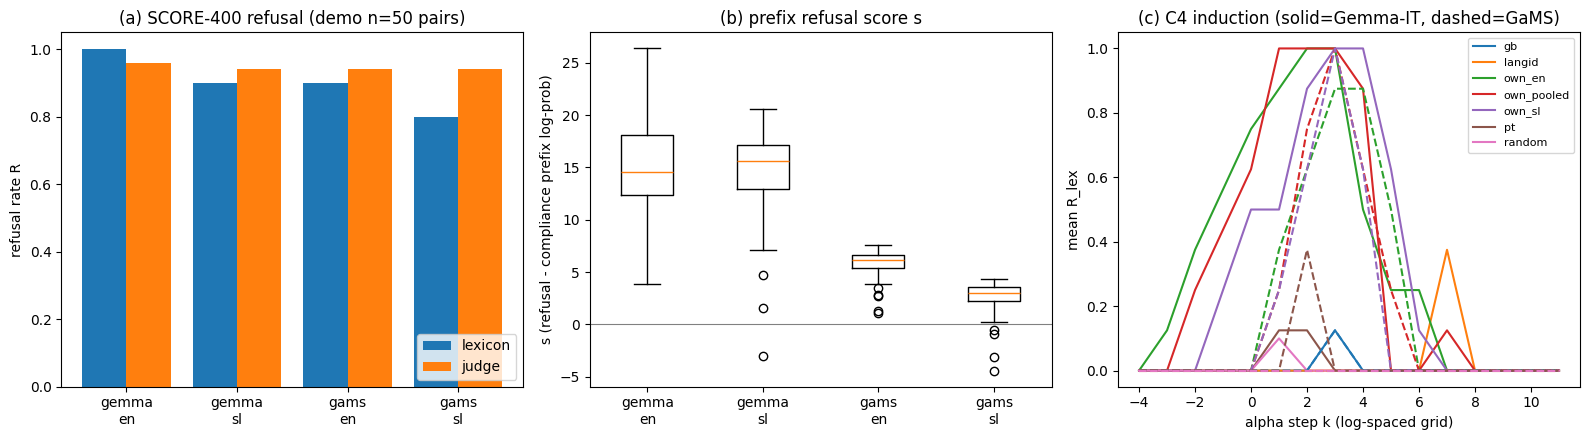

In [12]:
ds = {d["dataset"]: d["examples"] for d in out["datasets"]}
d1 = pd.DataFrame(ds["RefusEU_SCORE400_generation_EN_SL"])
d2 = pd.DataFrame(ds["RefusEU_SCORE_all_pairs_refusal_score_s"])
d3 = ds["alpaca_harmless_C4_induction"]
print({k: len(v) for k, v in ds.items()})

tab = []
for m in ["gemma", "gams"]:
    for lang in ["en", "sl"]:
        sub = d1[d1.metadata_lang == lang]
        tab.append({"model": m, "lang": lang, "n": len(sub),
                    "R_lexicon": sub[f"metadata_R_lex_{m}"].mean(),
                    "R_judge": (sub[f"metadata_judge_{m}"] == "refuse").mean(),
                    "degenerate": sub[f"metadata_degenerate_{m}"].mean(),
                    "s_mean": d2[d2.metadata_lang == lang][f"metadata_s_{m}"].mean()})
tab = pd.DataFrame(tab)
print("\nDemo-subset summary (dataset 1 / dataset 2):")
print(tab.round(3).to_string(index=False))

fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
x = np.arange(len(tab)); lbl = [f"{r.model}\n{r.lang}" for r in tab.itertuples()]
ax[0].bar(x - 0.2, tab.R_lexicon, 0.4, label="lexicon")
ax[0].bar(x + 0.2, tab.R_judge, 0.4, label="judge")
ax[0].set_xticks(x, lbl); ax[0].set_ylim(0, 1.05); ax[0].set_ylabel("refusal rate R"); ax[0].legend(loc="lower right")
ax[0].set_title(f"(a) SCORE-400 refusal (demo n={len(d1) // 2} pairs)")

ax[1].boxplot([d2[d2.metadata_lang == l][f"metadata_s_{m}"] for m in ["gemma", "gams"] for l in ["en", "sl"]])
ax[1].set_xticks(range(1, 5), lbl); ax[1].axhline(0, color="grey", lw=0.8)
ax[1].set_ylabel("s (refusal - compliance prefix log-prob)"); ax[1].set_title("(b) prefix refusal score s")

fam = lambda d: "random" if d.startswith("rand") else d
for m, ls in [("gemma", "-"), ("gams", "--")]:
    curves = {}
    for e in d3:
        if e["metadata_direction"] == "none":
            continue
        curves.setdefault(fam(e["metadata_direction"]), []).append((e["metadata_alpha_k"], e[f"metadata_R_by_alpha_{m}"]))
    for i, (f, lst) in enumerate(sorted(curves.items())):
        ks = sorted({k for ak, _ in lst for k in ak})
        mean_r = [np.mean([r[ak.index(k)] for ak, r in lst if k in ak]) for k in ks]
        ax[2].plot(ks, mean_r, ls, color=f"C{i}", label=f"{f}" if m == "gemma" else None)
ax[2].set_xlabel("alpha step k (log-spaced grid)"); ax[2].set_ylabel("mean R_lex")
ax[2].set_title("(c) C4 induction (solid=Gemma-IT, dashed=GaMS)"); ax[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

**How to read this.** The demo subset is small, so its rates are noisy. The conclusions come from the full-data
headline block above:

* ALT-2 fails: base-model separability does not favour GaMS in SL at the pre-registered layer.
* C4 takes the failure branch: the ancestor (pt) direction is not a refusal gate that both models can read.
* Behaviourally, the GaMS SL refusal deficit is small under the judge. Its DiD CI includes 0.

For the full run, point `ROOT` at the artifact directory, which holds all of `results/`, and call `build()`.